<h3 style="color:tomato"><b>Financial Transaction Monitoring and Fraud Anomaly Detection using Time-Series Forecasting </b></h3>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<h4 style='color:tomato'>Data Collection</h4>

In [2]:
df = pd.read_csv("transactions.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


<h4 style='color:tomato'>Data Cleaning</h4>

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [8]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

<h4 style='color:tomato'>Feature Engineering and EDA</h4>

In [9]:
df["hour"] = df["step"]
df["day"] = df["step"] // 24

In [10]:
suspicious = df[df["type"].isin(["CASH_OUT", "TRANSFER"])]

In [11]:
daily_amount = suspicious.groupby("day")["amount"].sum()
daily_amount.head()

day
0    6.838778e+10
1    5.263513e+10
2    7.599079e+08
3    2.412153e+09
4    1.333773e+09
Name: amount, dtype: float64

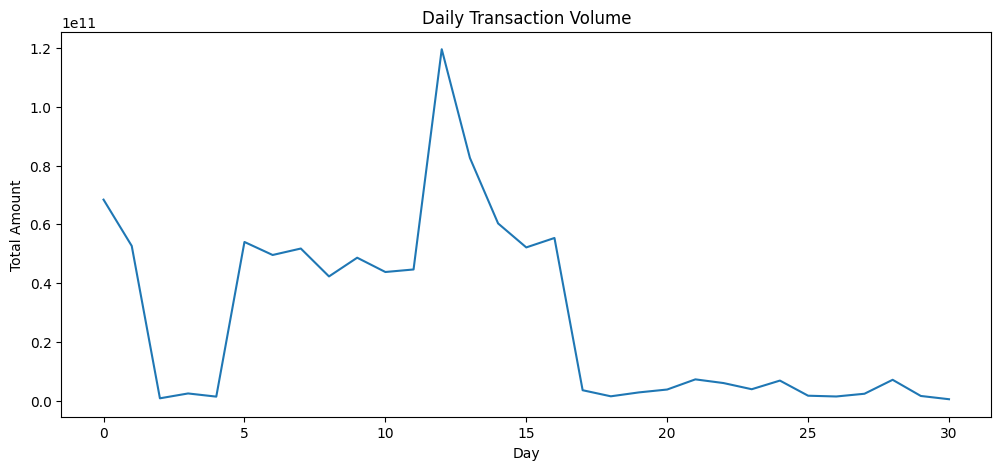

In [12]:
plt.figure(figsize=(12,5))
plt.plot(daily_amount)
plt.title("Daily Transaction Volume")
plt.xlabel("Day")
plt.ylabel("Total Amount")
plt.show()

In [13]:
daily_amount.describe()

count    3.100000e+01
mean     2.837758e+10
std      3.129453e+10
min      4.497035e+08
25%      2.362586e+09
50%      7.060646e+09
75%      5.193731e+10
max      1.195936e+11
Name: amount, dtype: float64

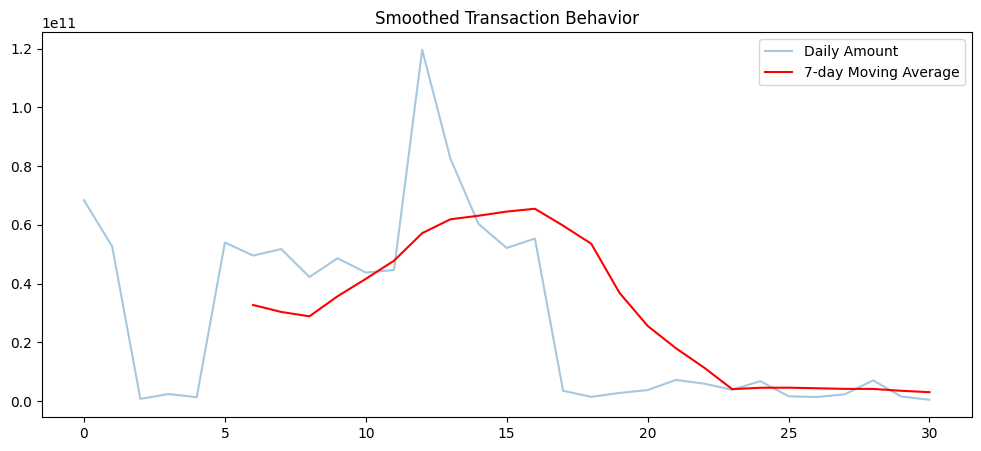

In [14]:
rolling_mean = daily_amount.rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_amount, alpha=0.4, label="Daily Amount")
plt.plot(rolling_mean, color="red", label="7-day Moving Average")
plt.legend()
plt.title("Smoothed Transaction Behavior")
plt.show()

<h4 style='color:tomato'>ARIMA Modeling</h4>

<h5>Stationarity Check: Augmented Dickey-Fuller (ADF) test and Differencing</h5>

In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_amount)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.276181739692382
p-value: 0.17976492841524438


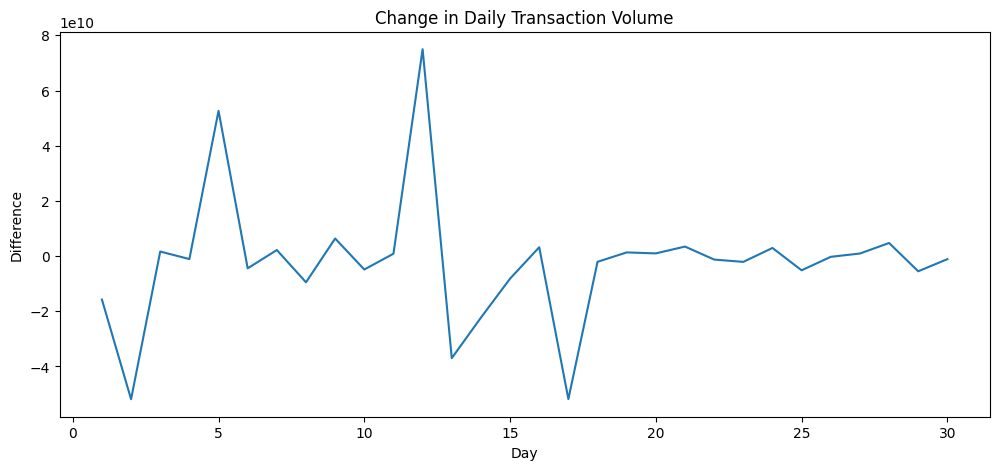

In [16]:
daily_diff = daily_amount.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(daily_diff)
plt.title("Change in Daily Transaction Volume")
plt.xlabel("Day")
plt.ylabel("Difference")
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_diff)
print(f"p-value: {result[1]:.9f}")

p-value: 0.000000501


<h5>Identifying p and q values: PACF, ACF</h5>

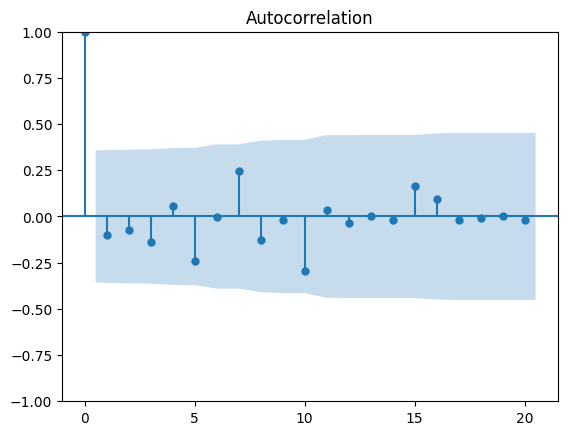

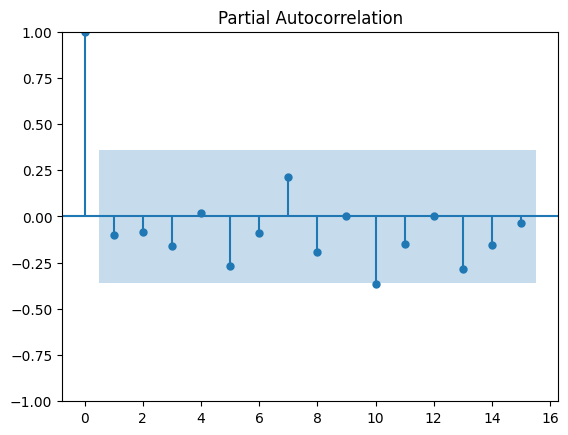

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(daily_diff, lags=20)
plt.show()

plot_pacf(daily_diff, lags=15)
plt.show()

<h5>ARIMA</h5>

In [19]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(daily_amount, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 amount   No. Observations:                   31
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -756.929
Date:                Wed, 18 Feb 2026   AIC                           1519.858
Time:                        01:09:26   BIC                           1524.062
Sample:                             0   HQIC                          1521.203
                                 - 31                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7222      0.240      3.008      0.003       0.252       1.193
ma.L1         -0.9793      0.205     -4.770      0.000      -1.382      -0.577
sigma2      4.765e+20   4.99e-22   9.55e+41      0.0

c:\Users\Jeswin\Downloads\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [20]:
pred = model_fit.predict(start=1, end=len(daily_amount)-1)

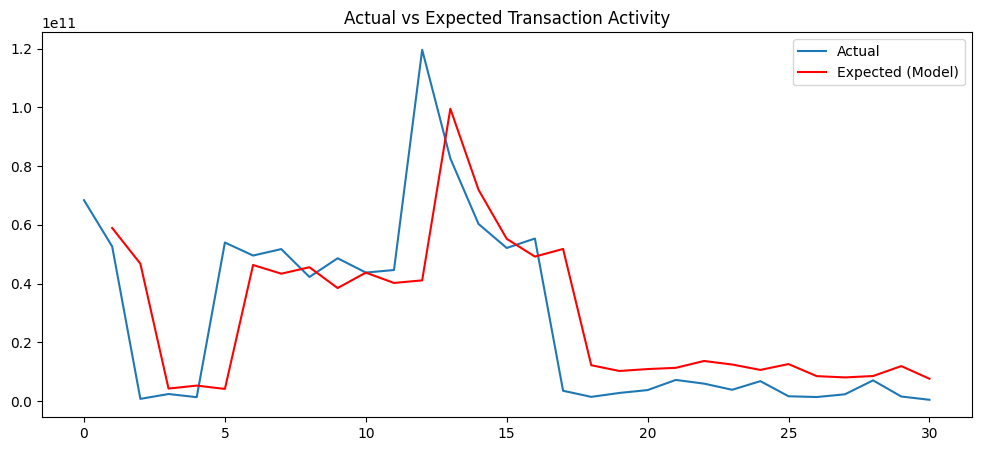

In [21]:
plt.figure(figsize=(12,5))
plt.plot(daily_amount, label="Actual")
plt.plot(pred, color="red", label="Expected (Model)")
plt.legend()
plt.title("Actual vs Expected Transaction Activity")
plt.show()

<h4 style='color:tomato'>Anomaly Detection</h4>

<h5>Z-score</h5>

In [22]:
residuals = daily_amount - pred
residuals.head()

day
0             NaN
1   -6.301537e+09
2   -4.602562e+10
3   -1.856859e+09
4   -3.944326e+09
dtype: float64

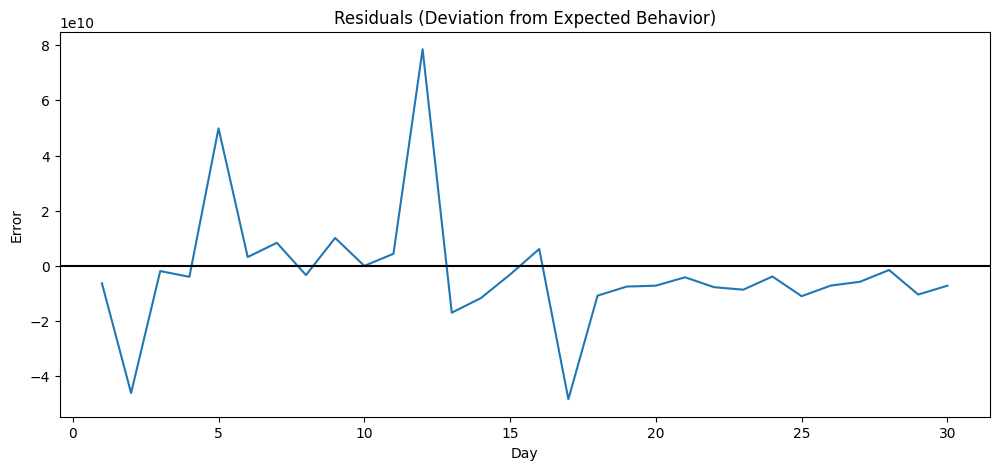

In [23]:
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.axhline(0, color='black')
plt.title("Residuals (Deviation from Expected Behavior)")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

In [24]:
Z = (residuals - residuals.mean()) / residuals.std()

In [25]:
anomalies = residuals[abs(Z)>2.5]
anomalies

day
12    7.849924e+10
dtype: float64

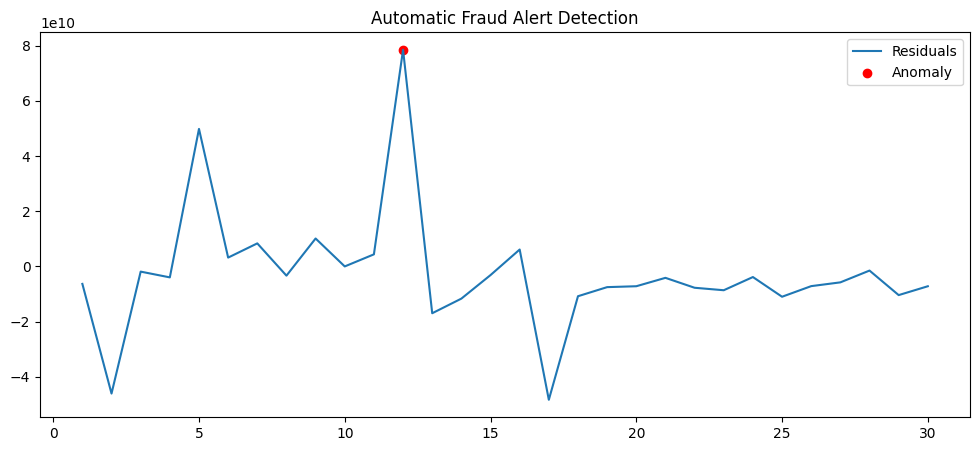

In [26]:
plt.figure(figsize=(12,5))
plt.plot(residuals, label="Residuals")
plt.scatter(anomalies.index, anomalies, color='red', label="Anomaly")
plt.legend()
plt.title("Automatic Fraud Alert Detection")
plt.show()

<h5>Isolation Forest</h5>

In [27]:
from sklearn.ensemble import IsolationForest

X = daily_amount.values.reshape(-1,1)

iso = IsolationForest(contamination=0.1, random_state=42)
labels = iso.fit_predict(X)

In [28]:
ml_anomalies = daily_amount[labels == -1]
ml_anomalies

day
0     6.838778e+10
12    1.195936e+11
13    8.260016e+10
Name: amount, dtype: float64

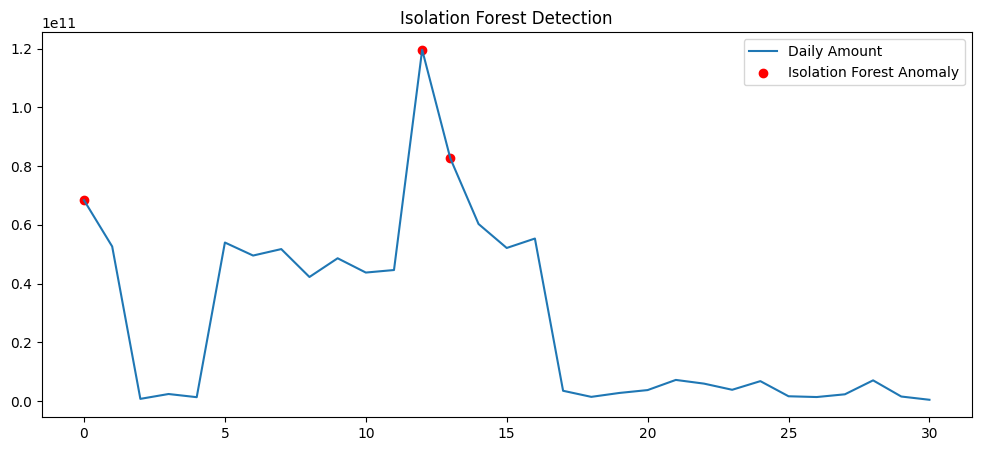

In [29]:
plt.figure(figsize=(12,5))
plt.plot(daily_amount, label="Daily Amount")
plt.scatter(ml_anomalies.index, ml_anomalies,
            color='red', label="Isolation Forest Anomaly")
plt.legend()
plt.title("Isolation Forest Detection")
plt.show()